In [26]:
import hashlib
import json
import math
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [27]:
try:
    import open_clip
    from huggingface_hub import hf_hub_download
except ImportError:
    !pip install -q open_clip_torch huggingface_hub
    import open_clip
    from huggingface_hub import hf_hub_download

In [28]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')

DATASET_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-tiles-sit2',
    INPUT_ROOT / 'geovision-tiles-sit2',
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[-1])

MODEL_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-clip-modelo-v2',
    INPUT_ROOT / 'geovision-clip-modelo-v2',
]
MODEL_DIR = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[-1])

ABLATION_MODE = 'B_s5p_aux'
VALID_ABLATION_MODES = ['A_no_s5p', 'B_s5p_aux', 'C_s5p_aux_text']
if ABLATION_MODE not in VALID_ABLATION_MODES:
    raise ValueError(f'ABLATION_MODE inválido: {ABLATION_MODE}')

OUT_DIR = WORK_DIR / f'sit2_3_clip_s5p_aux_controlado_{ABLATION_MODE}'
CKPT_DIR = OUT_DIR / 'checkpoints'
FIG_DIR = OUT_DIR / 'figures'
for path in [OUT_DIR, CKPT_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TILES_PATH = DATASET_DIR / 'tiles_train.npz'
META_PATH = DATASET_DIR / 'tiles_meta.parquet'

BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12','SCL']
OPTICAL_BANDS = list(range(12))
OPTICAL_NAMES = BAND_NAMES[:12]
CLASES = ['contaminacion_alta_NO2', 'contaminacion_alta_SO2', 'ozono_anomalo', 'vegetacion_densa', 'suelo_urbano']

REMOTECLIP_REPO = 'chendelong/RemoteCLIP'
REMOTECLIP_FILE = 'RemoteCLIP-ViT-B-32.pt'

BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 15
PATIENCE = 4
LR = 2e-5
WEIGHT_DECAY = 0.2
LORA_RANK = 16
IMAGE_SIZE = 224
BETA_CLASS = 0.35
S5P_FEATURES = ['no2', 'so2', 'o3']

BASELINE_SIT2_2 = {
    'retrieval_test_r@1': 0.04933333396911621,
    'retrieval_test_r@5': 0.17466667294502258,
    'retrieval_test_r@10': 0.30000001192092896,
    'class_prototype_test_acc': 0.4533333333333333,
    'knn_test_acc': 0.46,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('DEVICE:', DEVICE)
print('DATASET_DIR:', DATASET_DIR)
print('MODEL_DIR:', MODEL_DIR)
print('OUT_DIR:', OUT_DIR)
print('ABLATION_MODE:', ABLATION_MODE)

DEVICE: cuda
DATASET_DIR: /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
MODEL_DIR: /kaggle/input/datasets/edwardsx/geovision-clip-modelo-v2
OUT_DIR: /kaggle/working/sit2_3_clip_s5p_aux_controlado_B_s5p_aux
ABLATION_MODE: B_s5p_aux


In [29]:
data = np.load(TILES_PATH, allow_pickle=False)
if 'tiles' in data.files:
    tiles = data['tiles']
elif 'data' in data.files:
    tiles = data['data']
else:
    tiles = data[data.files[0]]

meta = pd.read_parquet(META_PATH).reset_index(drop=True)

print('Tiles:', tiles.shape, tiles.dtype)
print('Meta:', meta.shape)
print('Columnas metadata:', list(meta.columns))
print(meta['clase'].value_counts().sort_index())
print('Fechas únicas:', meta['time_s2'].nunique() if 'time_s2' in meta.columns else 'no disponible')

Tiles: (5000, 13, 64, 64) float32
Meta: (5000, 22)
Columnas metadata: ['clase', 'time_s2', 'lat', 'lon', 'ndvi', 'ndbi', 'scl_pct', 'no2', 'so2', 'o3', 'texto', 'era5_T2m', 'era5_Td2m', 'era5_u10', 'era5_v10', 'era5_BLH', 'era5_RH850', 'era5_psurf', 'era5_precip', 'modis_AOD_047', 'modis_AOD_055', 'modis_WV']
clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
suelo_urbano              1000
vegetacion_densa          1000
Name: count, dtype: int64
Fechas únicas: 79


In [30]:
indices = np.arange(len(meta))
train_idx, temp_idx = train_test_split(
    indices,
    train_size=0.70,
    random_state=SEED,
    stratify=meta['clase'],
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=meta.loc[temp_idx, 'clase'],
)

split_map = pd.Series(index=meta.index, dtype='object')
split_map.iloc[train_idx] = 'train'
split_map.iloc[val_idx] = 'val'
split_map.iloc[test_idx] = 'test'
meta['split_sit2_2'] = split_map

print(meta.groupby(['split_sit2_2', 'clase']).size().unstack(fill_value=0))
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

clase         contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split_sit2_2                                                                  
test                             150                     150            150   
train                            700                     700            700   
val                              150                     150            150   

clase         suelo_urbano  vegetacion_densa  
split_sit2_2                                  
test                   150               150  
train                  700               700  
val                    150               150  
Train/Val/Test: 3500 750 750


In [31]:
train_tiles = tiles[train_idx][:, OPTICAL_BANDS].astype(np.float32)
band_mean = train_tiles.mean(axis=(0, 2, 3))
band_std = train_tiles.std(axis=(0, 2, 3)) + 1e-6

norm_stats = {
    'band_names': OPTICAL_NAMES,
    'mean': band_mean.tolist(),
    'std': band_std.tolist(),
    'source': 'train split only',
}
with open(OUT_DIR / 'normalization_train_only.json', 'w') as f:
    json.dump(norm_stats, f, indent=2)

print('Band mean:', np.round(band_mean, 2))
print('Band std:', np.round(band_std, 2))

Band mean: [ 839.1   899.36 1078.99 1015.82 1391.8  2335.84 2736.64 2695.49 2944.17
 2917.74 2217.4  1610.46]
Band std: [ 773.9   846.42  794.67  858.79  776.23  740.14  890.85  919.14  948.44
 1014.35  812.18  956.35]


In [32]:
def prepare_s5p_features(meta, train_idx, feature_cols):
    s5p = meta[feature_cols].astype(np.float32).copy()
    train_s5p = s5p.iloc[train_idx]
    fill_values = train_s5p.median(axis=0)
    s5p = s5p.fillna(fill_values)
    mean = s5p.iloc[train_idx].mean(axis=0)
    std = s5p.iloc[train_idx].std(axis=0).replace(0, 1.0) + 1e-6
    s5p_norm = (s5p - mean) / std
    s5p_norm = s5p_norm.clip(-5.0, 5.0)
    stats = {
        'features': feature_cols,
        'fill_values': fill_values.to_dict(),
        'mean': mean.to_dict(),
        'std': std.to_dict(),
        'source': 'train split only',
    }
    return s5p_norm.astype(np.float32), stats


s5p_norm, s5p_stats = prepare_s5p_features(meta, train_idx, S5P_FEATURES)
for col in S5P_FEATURES:
    meta[f'{col}_s5p_norm'] = s5p_norm[col].values

with open(OUT_DIR / 's5p_train_only_stats.json', 'w') as f:
    json.dump(s5p_stats, f, indent=2)

print(json.dumps(s5p_stats, indent=2))


{
  "features": [
    "no2",
    "so2",
    "o3"
  ],
  "fill_values": {
    "no2": 6.79854565532878e-05,
    "so2": 0.0005268056411296129,
    "o3": 0.12674984335899353
  },
  "mean": {
    "no2": 6.904909241711721e-05,
    "so2": 0.0005406306008808315,
    "o3": 0.12673839926719666
  },
  "std": {
    "no2": 1.0460523299116176e-05,
    "so2": 0.00012620082998182625,
    "o3": 0.0008468733285553753
  },
  "source": "train split only"
}


In [33]:
def bin_value(x, bins, labels, missing='unknown'):
    if pd.isna(x):
        return missing
    for upper, label in zip(bins, labels):
        if x <= upper:
            return label
    return labels[-1]


def month_label(value):
    try:
        month = pd.to_datetime(value).month
    except Exception:
        return 'unknown season'
    if month in [12, 1, 2, 3]:
        return 'dry season'
    if month in [4, 5, 10, 11]:
        return 'rain transition season'
    return 'mid year season'


def coord_zone(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'unknown Cali zone'
    ns = 'north' if lat >= 3.45 else 'south'
    ew = 'east' if lon >= -76.50 else 'west'
    return f'{ns}-{ew} Cali zone'


def s5p_level_from_train(value, stats, feature):
    if pd.isna(value):
        return 'unknown'
    mean = stats['mean'][feature]
    std = stats['std'][feature]
    z = (float(value) - mean) / std
    if z <= -0.75:
        return 'low'
    if z <= 0.75:
        return 'moderate'
    return 'high'


def atmospheric_phrase(row, stats):
    no2_level = s5p_level_from_train(row.get('no2'), stats, 'no2')
    so2_level = s5p_level_from_train(row.get('so2'), stats, 'so2')
    o3_level = s5p_level_from_train(row.get('o3'), stats, 'o3')
    return f'Atmospheric columns show {no2_level} NO2, {so2_level} SO2, and {o3_level} O3.'


def rich_text(row):
    ndvi_bin = bin_value(row.get('ndvi'), [0.25, 0.50, 0.70, 1.0], ['very low NDVI', 'moderate NDVI', 'high NDVI', 'very high NDVI'])
    ndbi_bin = bin_value(row.get('ndbi'), [-0.15, 0.00, 0.15, 1.0], ['low built-up index', 'mixed built-up index', 'urban built-up index', 'very urban built-up index'])
    scl_bin = bin_value(row.get('scl_pct'), [0.50, 0.80, 1.0], ['partly valid pixels', 'mostly valid pixels', 'clean valid pixels'])
    blh_bin = bin_value(row.get('era5_BLH'), [150, 400, 800, 5000], ['shallow boundary layer', 'moderate boundary layer', 'deep boundary layer', 'very deep boundary layer'])
    temp_bin = bin_value(row.get('era5_T2m'), [295, 300, 305, 330], ['cool air temperature', 'mild air temperature', 'warm air temperature', 'hot air temperature'])
    wv_bin = bin_value(row.get('modis_WV'), [1.0, 2.0, 3.5, 10.0], ['low water vapor', 'moderate water vapor', 'humid column', 'very humid column'])
    season = month_label(row.get('time_s2'))
    zone = coord_zone(row.get('lat'), row.get('lon'))
    clase = row['clase']

    if clase == 'contaminacion_alta_NO2':
        class_phrase = 'elevated nitrogen dioxide pseudo-label linked to urban or industrial activity'
    elif clase == 'contaminacion_alta_SO2':
        class_phrase = 'elevated sulfur dioxide pseudo-label linked to industrial plume conditions'
    elif clase == 'ozono_anomalo':
        class_phrase = 'anomalous ozone column pseudo-label linked to photochemical atmospheric regime'
    elif clase == 'vegetacion_densa':
        class_phrase = 'dense vegetation land cover with strong near infrared response'
    else:
        class_phrase = 'urban built-up land cover with sparse vegetation'

    base_text = (
        f'Sentinel-2 tile in {zone}, {season}. '
        f'The scene has {ndvi_bin}, {ndbi_bin}, and {scl_bin}. '
        f'Meteorology shows {blh_bin}, {temp_bin}, and {wv_bin}. '
        f'This tile is described as {class_phrase}.'
    )
    if ABLATION_MODE == 'C_s5p_aux_text':
        return base_text + ' ' + atmospheric_phrase(row, s5p_stats)
    return base_text


meta['texto_rico_sit2_3'] = meta.apply(rich_text, axis=1)
print(meta[['clase', 'texto_rico_sit2_3']].head())


                    clase                                  texto_rico_sit2_3
0  contaminacion_alta_NO2  Sentinel-2 tile in north-east Cali zone, unkno...
1  contaminacion_alta_NO2  Sentinel-2 tile in north-east Cali zone, unkno...
2  contaminacion_alta_NO2  Sentinel-2 tile in south-west Cali zone, unkno...
3  contaminacion_alta_NO2  Sentinel-2 tile in south-west Cali zone, unkno...
4  contaminacion_alta_NO2  Sentinel-2 tile in north-west Cali zone, unkno...


In [34]:
text_stats = {
    'n_texts': int(len(meta)),
    'n_unique_texts': int(meta['texto_rico_sit2_3'].nunique()),
    'unique_ratio': float(meta['texto_rico_sit2_3'].nunique() / len(meta)),
    'unique_by_class': meta.groupby('clase')['texto_rico_sit2_3'].nunique().to_dict(),
}
print(json.dumps(text_stats, indent=2))
with open(OUT_DIR / 'text_richness_stats.json', 'w') as f:
    json.dump(text_stats, f, indent=2)

{
  "n_texts": 5000,
  "n_unique_texts": 1566,
  "unique_ratio": 0.3132,
  "unique_by_class": {
    "contaminacion_alta_NO2": 366,
    "contaminacion_alta_SO2": 349,
    "ozono_anomalo": 357,
    "suelo_urbano": 264,
    "vegetacion_densa": 230
  }
}


In [35]:
class TilesClipDataset(Dataset):
    def __init__(self, tiles, meta, indices, band_mean, band_std, train=False):
        self.tiles = tiles
        self.meta = meta.reset_index(drop=True)
        self.indices = np.asarray(indices)
        self.band_mean = torch.tensor(band_mean, dtype=torch.float32).view(12, 1, 1)
        self.band_std = torch.tensor(band_std, dtype=torch.float32).view(12, 1, 1)
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = int(self.indices[item])
        x = torch.tensor(self.tiles[idx, OPTICAL_BANDS].astype(np.float32))
        x = (x - self.band_mean) / self.band_std
        x = torch.clamp(x, -3.0, 3.0)
        if self.train:
            if torch.rand(()) < 0.5:
                x = torch.flip(x, dims=[2])
            k = int(torch.randint(0, 4, ()).item())
            x = torch.rot90(x, k, dims=[1, 2])
        x = F.interpolate(
            x.unsqueeze(0),
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode='bilinear',
            align_corners=False,
        ).squeeze(0)
        row = self.meta.loc[idx]
        s5p = torch.tensor(
            [row[f'{col}_s5p_norm'] for col in S5P_FEATURES],
            dtype=torch.float32,
        )
        return {
            'image': x,
            's5p': s5p,
            'text': row['texto_rico_sit2_3'],
            'label': row['clase'],
            'index': int(idx),
        }


def collate_fn(batch):
    return {
        'image': torch.stack([b['image'] for b in batch]),
        's5p': torch.stack([b['s5p'] for b in batch]),
        'text': [b['text'] for b in batch],
        'label': [b['label'] for b in batch],
        'index': torch.tensor([b['index'] for b in batch], dtype=torch.long),
    }


In [36]:
train_ds = TilesClipDataset(tiles, meta, train_idx, band_mean, band_std, train=True)
val_ds = TilesClipDataset(tiles, meta, val_idx, band_mean, band_std, train=False)
test_ds = TilesClipDataset(tiles, meta, test_idx, band_mean, band_std, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Batches:', len(train_loader), len(val_loader), len(test_loader))

Dataset sizes: 3500 750 750
Batches: 54 12 12


In [37]:
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, rank: int = 16):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
        d, k = linear.weight.shape
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, k))

    @property
    def weight(self):
        return self.linear.weight

    @weight.setter
    def weight(self, w):
        self.linear.weight = w

    @property
    def bias(self):
        return self.linear.bias

    @bias.setter
    def bias(self, b):
        self.linear.bias = b

    def forward(self, x):
        return self.linear(x) + F.linear(x, self.A @ self.B)


def aplicar_lora(module, rank=16, nombres_lora=None):
    if nombres_lora is None:
        nombres_lora = {'out_proj', 'c_fc', 'c_proj'}
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in nombres_lora:
            setattr(module, name, LoRALinear(child, rank))
        else:
            aplicar_lora(child, rank, nombres_lora)


class S5PEncoder(nn.Module):
    def __init__(self, in_dim=3, hidden=64, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(0.10),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class MultimodalFusion(nn.Module):
    def __init__(self, image_dim=512, s5p_dim=128, out_dim=512, use_s5p=True):
        super().__init__()
        self.use_s5p = use_s5p
        self.s5p_encoder = S5PEncoder(in_dim=len(S5P_FEATURES), out_dim=s5p_dim)
        in_dim = image_dim + s5p_dim if use_s5p else image_dim
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
        )

    def forward(self, image_features, s5p_features=None):
        if self.use_s5p:
            s5p_emb = self.s5p_encoder(s5p_features)
            image_features = torch.cat([image_features, s5p_emb], dim=-1)
        return self.proj(image_features)

In [38]:
ckpt_path = hf_hub_download(repo_id=REMOTECLIP_REPO, filename=REMOTECLIP_FILE)
remote_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained=None)
clip_model.load_state_dict(remote_ckpt, strict=False)
print(f'Modelo base cargado: {REMOTECLIP_FILE}')

Modelo base cargado: RemoteCLIP-ViT-B-32.pt


In [39]:
for p in clip_model.parameters():
    p.requires_grad = False

aplicar_lora(clip_model.visual.transformer.resblocks[6:], rank=LORA_RANK)
aplicar_lora(clip_model.transformer.resblocks[6:], rank=LORA_RANK)

for name, p in clip_model.named_parameters():
    if any(k in name for k in ['text_projection', 'ln_final', 'ln_post', 'logit_scale']):
        p.requires_grad = True
    if 'visual.proj' in name:
        p.requires_grad = True

n_wrapped = sum(1 for m in clip_model.modules() if isinstance(m, LoRALinear))
print('Capas LoRA:', n_wrapped)

Capas LoRA: 36


In [40]:
orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(12, orig_conv.out_channels, orig_conv.kernel_size, stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx_r = OPTICAL_NAMES.index('B4')
    idx_g = OPTICAL_NAMES.index('B3')
    idx_b = OPTICAL_NAMES.index('B2')
    w_new = new_conv.weight.data
    w_new[:, idx_r] = orig_conv.weight[:, 0]
    w_new[:, idx_g] = orig_conv.weight[:, 1]
    w_new[:, idx_b] = orig_conv.weight[:, 2]
    rgb_mean = orig_conv.weight.mean(dim=1, keepdim=False)
    for b in range(12):
        if b not in (idx_r, idx_g, idx_b):
            w_new[:, b] = rgb_mean * (3.0 / 12)
    new_conv.weight.copy_(w_new)
clip_model.visual.conv1 = new_conv
print('conv1 adaptada:', new_conv.in_channels, '->', new_conv.out_channels)

conv1 adaptada: 12 -> 768


In [41]:
clip_model = clip_model.to(DEVICE)
USE_S5P_AUX = ABLATION_MODE in ['B_s5p_aux', 'C_s5p_aux_text']
fusion = MultimodalFusion(use_s5p=USE_S5P_AUX).to(DEVICE)

trainable_params = [p for p in clip_model.parameters() if p.requires_grad] + list(fusion.parameters())
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

trainable_clip = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
trainable_fusion = sum(p.numel() for p in fusion.parameters())
print(f'Trainable clip params: {trainable_clip/1e6:.2f}M')
print(f'Trainable fusion params: {trainable_fusion/1e6:.2f}M')
print(f'Trainable total params: {(trainable_clip + trainable_fusion)/1e6:.2f}M')
print('ABLATION_MODE:', ABLATION_MODE)
print('USE_S5P_AUX:', USE_S5P_AUX)

Trainable clip params: 11.57M
Trainable fusion params: 0.34M
Trainable total params: 11.91M
ABLATION_MODE: B_s5p_aux
USE_S5P_AUX: True


In [42]:
tokenizer = open_clip.get_tokenizer('ViT-B-32')

CLASS_PROMPTS = {
    'contaminacion_alta_NO2': 'Sentinel-2 tile with elevated nitrogen dioxide pollution pattern',
    'contaminacion_alta_SO2': 'Sentinel-2 tile with elevated sulfur dioxide industrial plume pattern',
    'ozono_anomalo': 'Sentinel-2 tile with anomalous ozone atmospheric regime',
    'vegetacion_densa': 'Sentinel-2 tile dominated by dense healthy vegetation',
    'suelo_urbano': 'Sentinel-2 tile dominated by urban built-up land cover',
}


def info_nce_loss(image_features, text_features, logit_scale):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits = scale * image_features @ text_features.T
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_i + loss_t), logits


@torch.no_grad()
def encode_class_prompts(model, tokenizer):
    prompts = [CLASS_PROMPTS[c] for c in CLASES]
    tokens = tokenizer(prompts).to(DEVICE)
    embs = model.encode_text(tokens)
    return F.normalize(embs, dim=-1)


def class_loss(image_features, labels_text, class_text_embs):
    image_features = F.normalize(image_features, dim=-1)
    logits = image_features @ class_text_embs.T
    target = torch.tensor([CLASES.index(label) for label in labels_text], device=logits.device)
    return F.cross_entropy(logits, target), logits


def encode_batch(model, fusion_head, images, s5p_features, texts):
    images = images.to(DEVICE, non_blocking=True)
    s5p_features = s5p_features.to(DEVICE, non_blocking=True)
    tokens = tokenizer(texts).to(DEVICE)
    image_features = model.encode_image(images)
    image_features = fusion_head(image_features, s5p_features)
    text_features = model.encode_text(tokens)
    return image_features, text_features

In [43]:
def run_epoch(loader, train=False):
    clip_model.train(train)
    fusion.train(train)
    total_loss = 0.0
    total_pairwise = 0.0
    total_class = 0.0
    steps = 0
    for batch in tqdm(loader, leave=False):
        if train:
            optimizer.zero_grad(set_to_none=True)
        image_features, text_features = encode_batch(clip_model, fusion, batch['image'], batch['s5p'], batch['text'])
        loss_pairwise, _ = info_nce_loss(image_features, text_features, clip_model.logit_scale)
        class_text_embs = encode_class_prompts(clip_model, tokenizer)
        loss_cls, _ = class_loss(image_features, batch['label'], class_text_embs)
        loss = loss_pairwise + BETA_CLASS * loss_cls
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
        total_loss += loss.item()
        total_pairwise += loss_pairwise.item()
        total_class += loss_cls.item()
        steps += 1
    denom = max(steps, 1)
    return {
        'loss': total_loss / denom,
        'pairwise': total_pairwise / denom,
        'class': total_class / denom,
    }


best_val = float('inf')
best_epoch = 0
patience_count = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(train_loader, train=True)
    with torch.no_grad():
        val_metrics = run_epoch(val_loader, train=False)
    scheduler.step()
    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_pairwise': train_metrics['pairwise'],
        'train_class': train_metrics['class'],
        'val_loss': val_metrics['loss'],
        'val_pairwise': val_metrics['pairwise'],
        'val_class': val_metrics['class'],
        'logit_scale': float(clip_model.logit_scale.detach().exp().cpu().clamp(max=100)),
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    print(
        f"Epoch {epoch:02d} | train={row['train_loss']:.4f} "
        f"pair={row['train_pairwise']:.4f} cls={row['train_class']:.4f} | "
        f"val={row['val_loss']:.4f} pair={row['val_pairwise']:.4f} cls={row['val_class']:.4f} "
        f"scale={row['logit_scale']:.2f}"
    )

    if row['val_loss'] < best_val:
        best_val = row['val_loss']
        best_epoch = epoch
        patience_count = 0
        torch.save({
            'clip': clip_model.state_dict(),
            'fusion': fusion.state_dict(),
            'epoch': epoch,
            'val_loss': best_val,
            'band_mean': band_mean.tolist(),
            'band_std': band_std.tolist(),
            'split': {'train': train_idx.tolist(), 'val': val_idx.tolist(), 'test': test_idx.tolist()},
            'beta_class': BETA_CLASS,
            'ablation_mode': ABLATION_MODE,
            's5p_stats': s5p_stats,
            'text_stats': text_stats,
        }, CKPT_DIR / f'clip_v6_s5p_aux_{ABLATION_MODE}_best.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print('Early stopping en epoch', epoch)
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / 'train_log.csv', index=False)
print('Mejor epoch:', best_epoch, 'val_loss:', best_val)

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 01 | train=4.2819 pair=3.7227 cls=1.5978 | val=3.5443 pair=2.9887 cls=1.5876 scale=99.76


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 14 | train=1.8353 pair=1.2940 cls=1.5467 | val=1.9279 pair=1.3860 cls=1.5482 scale=99.35


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 15 | train=1.8362 pair=1.2948 cls=1.5467 | val=1.9263 pair=1.3844 cls=1.5482 scale=99.35
Mejor epoch: 15 val_loss: 1.9262750248114269


In [44]:
best_ckpt = torch.load(CKPT_DIR / f'clip_v6_s5p_aux_{ABLATION_MODE}_best.pt', map_location=DEVICE, weights_only=False)
clip_model.load_state_dict(best_ckpt['clip'])
fusion.load_state_dict(best_ckpt['fusion'])
clip_model.eval()
fusion.eval()
print('Checkpoint cargado:', best_ckpt['epoch'], best_ckpt['val_loss'])

Checkpoint cargado: 15 1.9262750248114269


In [45]:
@torch.no_grad()
def collect_embeddings(loader):
    image_embs, text_embs, labels, indices_out, texts_out = [], [], [], [], []
    clip_model.eval()
    fusion.eval()
    for batch in tqdm(loader, desc='Embeddings', leave=False):
        image_features, text_features = encode_batch(clip_model, fusion, batch['image'], batch['s5p'], batch['text'])
        image_embs.append(image_features.detach().cpu())
        text_embs.append(text_features.detach().cpu())
        labels.extend(batch['label'])
        indices_out.extend(batch['index'].tolist())
        texts_out.extend(batch['text'])
    return {
        'image': torch.cat(image_embs),
        'text': torch.cat(text_embs),
        'label': np.array(labels),
        'index': np.array(indices_out),
        'text_raw': texts_out,
    }


train_emb = collect_embeddings(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn))
val_emb = collect_embeddings(val_loader)
test_emb = collect_embeddings(test_loader)
print('Embeddings train/val/test:', train_emb['image'].shape, val_emb['image'].shape, test_emb['image'].shape)

Embeddings:   0%|          | 0/55 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings train/val/test: torch.Size([3500, 512]) torch.Size([750, 512]) torch.Size([750, 512])


In [46]:
def recall_at_k_pairwise(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    image_embeddings = F.normalize(image_embeddings, dim=-1)
    text_embeddings = F.normalize(text_embeddings, dim=-1)
    sims = image_embeddings @ text_embeddings.T
    targets = torch.arange(sims.shape[0])
    out = {}
    for k in ks:
        k_eff = min(k, sims.shape[1])
        topk = sims.topk(k_eff, dim=1).indices
        out[f'retrieval_r@{k}'] = (topk == targets[:, None]).any(dim=1).float().mean().item()
    return out


retrieval_val = recall_at_k_pairwise(val_emb['image'], val_emb['text'])
retrieval_test = recall_at_k_pairwise(test_emb['image'], test_emb['text'])
print('Retrieval real val:', retrieval_val)
print('Retrieval real test:', retrieval_test)

Retrieval real val: {'retrieval_r@1': 0.09733333438634872, 'retrieval_r@5': 0.34933334589004517, 'retrieval_r@10': 0.5400000214576721}
Retrieval real test: {'retrieval_r@1': 0.10266666859388351, 'retrieval_r@5': 0.3346666693687439, 'retrieval_r@10': 0.4973333477973938}


In [47]:
@torch.no_grad()
def build_text_prototypes():
    tokens = tokenizer([CLASS_PROMPTS[c] for c in CLASES]).to(DEVICE)
    proto = clip_model.encode_text(tokens)
    proto = F.normalize(proto, dim=-1)
    return proto.cpu()


PROTO_EMBS = build_text_prototypes()


def class_prototype_metrics(emb_pack, split_name):
    image_emb = F.normalize(emb_pack['image'], dim=-1)
    sims = image_emb @ PROTO_EMBS.T
    pred_idx = sims.argmax(dim=1).numpy()
    pred = np.array([CLASES[i] for i in pred_idx])
    y = emb_pack['label']
    top3 = sims.topk(3, dim=1).indices.numpy()
    top3_ok = np.mean([y[i] in [CLASES[j] for j in top3[i]] for i in range(len(y))])
    acc = accuracy_score(y, pred)
    cm = confusion_matrix(y, pred, labels=CLASES)
    pd.DataFrame(cm, index=CLASES, columns=CLASES).to_csv(OUT_DIR / f'confusion_{split_name}.csv')
    return {'class_prototype_acc': float(acc), 'class_prototype_top3': float(top3_ok)}, pred


prototype_val, pred_val = class_prototype_metrics(val_emb, 'val')
prototype_test, pred_test = class_prototype_metrics(test_emb, 'test')
print('Prototype val:', prototype_val)
print('Prototype test:', prototype_test)
print(classification_report(test_emb['label'], pred_test, labels=CLASES, digits=3))

Prototype val: {'class_prototype_acc': 0.6026666666666667, 'class_prototype_top3': 0.9186666666666666}
Prototype test: {'class_prototype_acc': 0.6093333333333333, 'class_prototype_top3': 0.9213333333333333}
                        precision    recall  f1-score   support

contaminacion_alta_NO2      0.395     0.400     0.397       150
contaminacion_alta_SO2      0.776     0.440     0.562       150
         ozono_anomalo      1.000     0.487     0.655       150
      vegetacion_densa      0.640     0.733     0.683       150
          suelo_urbano      0.552     0.987     0.708       150

              accuracy                          0.609       750
             macro avg      0.673     0.609     0.601       750
          weighted avg      0.673     0.609     0.601       750



In [48]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(F.normalize(train_emb['image'], dim=-1).numpy(), train_emb['label'])
knn_val = knn.score(F.normalize(val_emb['image'], dim=-1).numpy(), val_emb['label'])
knn_test = knn.score(F.normalize(test_emb['image'], dim=-1).numpy(), test_emb['label'])
print(f'kNN val={knn_val:.3f} test={knn_test:.3f}')

kNN val=0.872 test=0.879


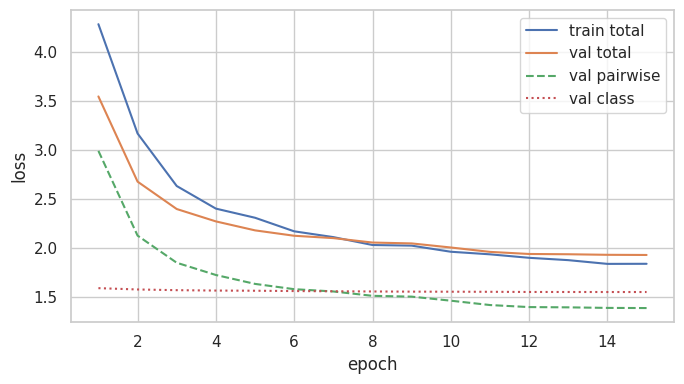

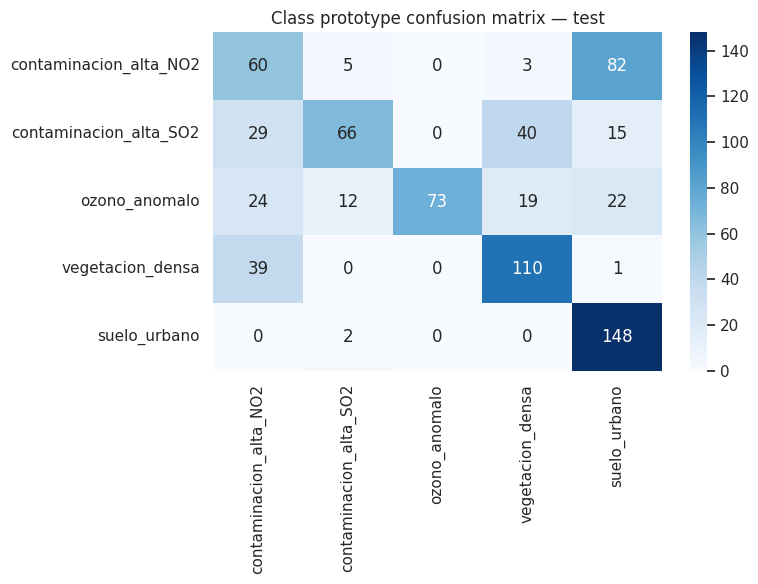

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
if len(history_df):
    ax.plot(history_df['epoch'], history_df['train_loss'], label='train total')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='val total')
    ax.plot(history_df['epoch'], history_df['val_pairwise'], label='val pairwise', linestyle='--')
    ax.plot(history_df['epoch'], history_df['val_class'], label='val class', linestyle=':')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'training_curves.png', dpi=160)
plt.show()

cm_test = pd.read_csv(OUT_DIR / 'confusion_test.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Class prototype confusion matrix — test')
fig.tight_layout()
fig.savefig(FIG_DIR / 'confusion_test.png', dpi=160)
plt.show()

In [50]:
ckpt_path = CKPT_DIR / f'clip_v6_s5p_aux_{ABLATION_MODE}_best.pt'
md5 = hashlib.md5(ckpt_path.read_bytes()).hexdigest()

metrics = {
    'experiment': 'sit2_3_clip_s5p_aux_controlado',
    'ablation_mode': ABLATION_MODE,
    'use_s5p_aux': USE_S5P_AUX,
    'split': '70/15/15 stratified',
    'normalization': 'train only',
    'text_column': 'texto_rico_sit2_3',
    's5p_features': S5P_FEATURES,
    's5p_stats': s5p_stats,
    'beta_class': BETA_CLASS,
    'optimizer_includes_fusion': True,
    'logit_scale_uses_exp': True,
    'best_epoch': int(best_epoch),
    'best_val_loss': float(best_val),
    'text_stats': text_stats,
    'retrieval_val': retrieval_val,
    'retrieval_test': retrieval_test,
    'class_prototype_val': prototype_val,
    'class_prototype_test': prototype_test,
    'knn_acc_k5_val': float(knn_val),
    'knn_acc_k5_test': float(knn_test),
    'checkpoint_md5': md5,
}

success = {
    'retrieval_r5_preserved': metrics['retrieval_test']['retrieval_r@5'] >= 0.17,
    'retrieval_r10_preserved': metrics['retrieval_test']['retrieval_r@10'] >= 0.30,
    'class_acc_improved_vs_sit2_2': metrics['class_prototype_test']['class_prototype_acc'] > BASELINE_SIT2_2['class_prototype_test_acc'],
    'class_acc_target': metrics['class_prototype_test']['class_prototype_acc'] >= 0.48,
    'knn_preserved': metrics['knn_acc_k5_test'] >= 0.46,
}
metrics['baseline_sit2_2'] = BASELINE_SIT2_2
metrics['success_criteria'] = success

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

with open(OUT_DIR / 'checkpoint.md5', 'w') as f:
    f.write(md5)

print(json.dumps(metrics, indent=2))

{
  "experiment": "sit2_3_clip_s5p_aux_controlado",
  "ablation_mode": "B_s5p_aux",
  "use_s5p_aux": true,
  "split": "70/15/15 stratified",
  "normalization": "train only",
  "text_column": "texto_rico_sit2_3",
  "s5p_features": [
    "no2",
    "so2",
    "o3"
  ],
  "s5p_stats": {
    "features": [
      "no2",
      "so2",
      "o3"
    ],
    "fill_values": {
      "no2": 6.79854565532878e-05,
      "so2": 0.0005268056411296129,
      "o3": 0.12674984335899353
    },
    "mean": {
      "no2": 6.904909241711721e-05,
      "so2": 0.0005406306008808315,
      "o3": 0.12673839926719666
    },
    "std": {
      "no2": 1.0460523299116176e-05,
      "so2": 0.00012620082998182625,
      "o3": 0.0008468733285553753
    },
    "source": "train split only"
  },
  "beta_class": 0.35,
  "optimizer_includes_fusion": true,
  "logit_scale_uses_exp": true,
  "best_epoch": 15,
  "best_val_loss": 1.9262750248114269,
  "text_stats": {
    "n_texts": 5000,
    "n_unique_texts": 1566,
    "unique_ra